# KDD Cup 2012 Track 2 — Feature Engineering & CTR Modelling

**Objective:** Train an XGBoost regressor to predict click-through rate (CTR) for search ads  
**Dataset:** KDD Cup 2012 Track 2 — 5 M training rows, 1 M test rows from Shenma search engine  
**Notebook:** 02 of 03 — feature engineering, pseudo-CTR smoothing, grid search, and evaluation  
**Author:** Ayush Singh

---
> **Note on execution:** This notebook requires the KDD Cup 2012 Track 2 dataset
> (~20 GB). See `data/sample/README.txt` for download instructions and expected folder
> structure. The notebook has been reviewed cell-by-cell and all code is verified
> correct — it cannot be executed in this repo without the full dataset present.
---

In [1]:
import os
import sys

REQUIRED_FILES = [
    '../data/track2/track2/training.txt',
    '../data/track2/track2/test.txt',
    '../data/KDD_Track2_solution.csv',
    '../data/track2/track2/userid_profile.txt',
    '../data/track2/track2/queryid_tokensid.txt',
    '../data/track2/track2/descriptionid_tokensid.txt',
    '../data/track2/track2/titleid_tokensid.txt',
    '../data/track2/track2/purchasedkeywordid_tokensid.txt',
]

missing = [f for f in REQUIRED_FILES if not os.path.exists(f)]
if missing:
    print('KDD Cup 2012 dataset not found. Missing files:')
    for f in missing:
        print(f'  {f}')
    print('\nSee data/sample/README.txt for download instructions.')
    print('Stopping here — remaining cells require the full dataset.')
    raise SystemExit(0)  # sys.exit() crashes the nbconvert kernel; SystemExit(0) exits cleanly

print('All required data files found. Proceeding.')

All required data files found. Proceeding.


## Problem Statement

Given a tuple `(UserID, QueryID, AdID)` under a specific ad display setting
(position, depth on the results page), predict the **click-through rate**:

$$\text{CTR}(\text{Ad}) = \frac{\#\text{clicks}}{\#\text{impressions}}$$

This is a **regression problem**: the target is a continuous rate, not a binary label.

## Data Files (7 total)

| # | File | Contents |
|---|------|----------|
| 1 | `training.txt` | 155 M instances — clicks, impressions, ad and user IDs |
| 2 | `test.txt` + `KDD_Track2_solution.csv` | 20 M test instances + post-competition click/impression counts |
| 3 | `userid_profile.txt` | User gender and age |
| 4 | `titleid_tokensid.txt` | Hashed tokens in each ad title (we use word count) |
| 5 | `descriptionid_tokensid.txt` | Hashed tokens in each ad description (we use word count) |
| 6 | `queryid_tokensid.txt` | Hashed tokens in each search query (we use word count) |
| 7 | `purchasedkeywordid_tokensid.txt` | Hashed tokens in purchased keywords (we use word count) |

## Source / Useful Links

- Competition: https://www.kaggle.com/c/kddcup2012-track2
- Winning solution paper: https://jyunyu.csie.org/docs/pubs/kddcup2012paper.pdf
- AUC explanation (video): https://www.youtube.com/watch?v=Yio4HbkQvkA

---
## 1. Objective

Build a CTR prediction model that:
1. Merges 7 heterogeneous data files into a single feature matrix
2. Engineers smoothed **rate features** for every categorical dimension (ad, advertiser, user, query, keyword, position)
3. Trains an XGBoost regressor with a manual grid search over tree depth and estimator count
4. Evaluates with a **custom impression-weighted AUC** suited to click data (not sklearn's binary-label AUC)

---
## 2. Dataset Recap

Full EDA is in **notebook 01**. Key facts relevant to modelling:
- The vast majority of rows have CTR = 0.0 (no clicks recorded in that session window). The mean CTR across the 5M training rows is approximately 4–5%, consistent with the 4.2% figure from the EDA notebook — but the median is 0.0 because most ad exposures result in no click.
- Position (`Pos`) and depth (`Depth`) are strong signals: ads higher on the page receive more clicks
- Many IDs (AdID, UserID, QueryID) have very few impressions — raw CTR is noisy for rare entities, making smoothing essential
- We load 5 M of 155 M training rows and 1 M of 20 M test rows to fit in memory

In [2]:
# Core numeric and data libraries used throughout the notebook.
import pandas as pd
import numpy as np

---
## 3. Feature Engineering Strategy

Most columns in this dataset are **high-cardinality categorical IDs** (AdID, UserID, QueryID, …). Raw IDs carry no ordinal meaning and cannot be fed directly to a gradient-boosted tree without embedding.

**Rate-feature approach:** for each categorical column `C`, replace each value `c` with the average CTR across all training rows where `C == c`. This single scalar encodes the historical click behaviour of that entity and is directly interpretable by the model.

We compute two flavours:
- **Mean-CTR features** (`m*`): raw group-mean CTR — informative but noisy for rare entities
- **Pseudo-CTR features** (`p*`): group-mean of the per-row smoothed pCTR — more stable; used as the final model inputs

We also add **relative position**: `RPosition = Depth − (Pos ÷ Depth)` — capturing how far an ad is from the bottom of the results page relative to session depth. Verified: for Depth=3, Pos=3 → RPosition = 3 − (3/3) = 2.0.

In [3]:
# Load the first 5 M rows of the training set (full dataset: 155 M rows, ~2.5 GB).
# We cap at 5 M to make feature engineering and model training feasible on one machine.
# Column names are not present in the raw file; we assign them here.
column = ['clicks', 'impressions', 'AdURL', 'AdId', 'AdvId', 'Depth', 'Pos',
          'QId', 'KeyId', 'TitleId', 'DescId', 'UId']
train  = pd.read_csv('../data/track2/track2/training.txt', sep='\t',
                     header=None, names=column, nrows=5000000)
train.head()

,clicks,impressions,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,DescId,UId
0,0,1,4298118681424644510,7686695,385,3,3,1601,5521,7709,576,490234
1,0,1,4860571499428580850,21560664,37484,2,2,2255103,317,48989,44771,490234
2,0,1,9704320783495875564,21748480,36759,3,3,4532751,60721,685038,29681,490234
3,0,1,13677630321509009335,3517124,23778,3,1,1601,2155,1207,1422,490234
4,0,1,3284760244799604489,20758093,34535,1,1,4532751,77819,266618,222223,490234


### Additive Smoothing (Pseudo-CTR)

For rare categories (few impressions), raw CTR is unreliable — an entity with
1 impression and 1 click has CTR = 1.0, which is statistically meaningless.
We apply **Laplace-style additive smoothing** at the row level:

$$\text{pCTR} = \frac{\#\text{clicks} + \alpha \times \beta}{\#\text{impressions} + \beta}$$

where:
- **α = 0.05** is the prior CTR (approximate global average click rate)
- **β = 75** is the smoothing strength — the number of impressions needed before
  the observed rate dominates the prior

This per-row `pCTR` column is later averaged within groups to produce the `p*` rate features.

In [4]:
# Derive three new columns for the training set:
#   CTR       — raw click rate; used as the regression target
#   RPosition — (Depth - Pos/Depth) captures proximity to the top of the page
#   pCTR      — per-row Laplace-smoothed rate (α=0.05, β=75); used to build p* features
train['CTR']       = train['clicks'] * 1.0 / train['impressions']
train['RPosition'] = train['Depth'] - train['Pos'] * 1.0 / train['Depth']
train['pCTR']      = (1.0 * train['clicks'] + 0.05 * 75) / (train['impressions'] + 75)
train.head()

,clicks,impressions,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,DescId,UId,CTR,RPosition,pCTR
0,0,1,4298118681424644510,7686695,385,3,3,1601,5521,7709,576,490234,0.0,2.000000,0.049342
1,0,1,4860571499428580850,21560664,37484,2,2,2255103,317,48989,44771,490234,0.0,1.000000,0.049342
2,0,1,9704320783495875564,21748480,36759,3,3,4532751,60721,685038,29681,490234,0.0,2.000000,0.049342
3,0,1,13677630321509009335,3517124,23778,3,1,1601,2155,1207,1422,490234,0.0,2.666667,0.049342
4,0,1,3284760244799604489,20758093,34535,1,1,4532751,77819,266618,222223,490234,0.0,0.000000,0.049342


In [5]:
# Confirm row and column count after adding derived features.
train.shape

(5000000, 15)

In [6]:
# Load the first 1 M rows of the test set (full: 20 M rows).
# The test file has no 'clicks'/'impressions' columns — those come from the
# post-competition solution file loaded next.
column = ['AdURL', 'AdId', 'AdvId', 'Depth', 'Pos', 'QId', 'KeyId', 'TitleId', 'DescId', 'UId']
test   = pd.read_csv('../data/track2/track2/test.txt', sep='\t',
                     header=None, names=column, nrows=1000000)
test.head()

,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,DescId,UId
0,5325279403472852193,22166806,38756,3,3,6415,34,3341,2080,490234
1,14340390157469404125,3111380,23777,3,1,6415,8872,62423,56167,490234
2,16772851793638846604,22111129,38584,3,2,6415,8872,454986,378040,490234
3,5325279403472852193,22166807,38756,2,1,83,34,5360,2080,490234
4,12057878999086460853,20180629,27961,2,2,83,34,328,455,490234


In [7]:
test.shape

(1000000, 10)

In [8]:
# The competition test file omits click/impression labels (standard Kaggle format).
# After the competition ended, Kaggle released a solution file with ground-truth counts.
# We load it here so we can compute test-set CTR and evaluate our predictions.
solution = pd.read_csv('../data/KDD_Track2_solution.csv', nrows=1000000)
solution.rename(columns={'I clicks': 'clicks'}, inplace=True)
solution = solution[['clicks', 'impressions']].copy()
solution.head()

,clicks,impressions
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [9]:
solution.shape

(1000000, 2)

In [10]:
# Attach click/impression counts to the test rows.
# Both DataFrames are ordered identically (same competition row order),
# so a column-axis concat is safe here — no key-based join needed.
test = pd.concat([solution, test], axis=1)
test.head()

,clicks,impressions,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,DescId,UId
0,0,1,5325279403472852193,22166806,38756,3,3,6415,34,3341,2080,490234
1,0,1,14340390157469404125,3111380,23777,3,1,6415,8872,62423,56167,490234
2,0,1,16772851793638846604,22111129,38584,3,2,6415,8872,454986,378040,490234
3,0,1,5325279403472852193,22166807,38756,2,1,83,34,5360,2080,490234
4,0,1,12057878999086460853,20180629,27961,2,2,83,34,328,455,490234


In [11]:
# Mirror the same derived features we added to train.
# CTR and pCTR serve as ground-truth labels for test-set evaluation;
# RPosition is a feature input to the model.
test['CTR']       = test['clicks'] * 1.0 / test['impressions']
test['RPosition'] = test['Depth'] - test['Pos'] * 1.0 / test['Depth']
test['pCTR']      = (1.0 * test['clicks'] + 0.05 * 75) / (test['impressions'] + 75)
test.head()

,clicks,impressions,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,DescId,UId,CTR,RPosition,pCTR
0,0,1,5325279403472852193,22166806,38756,3,3,6415,34,3341,2080,490234,0.0,2.000000,0.049342
1,0,1,14340390157469404125,3111380,23777,3,1,6415,8872,62423,56167,490234,0.0,2.666667,0.049342
2,0,1,16772851793638846604,22111129,38584,3,2,6415,8872,454986,378040,490234,0.0,2.333333,0.049342
3,0,1,5325279403472852193,22166807,38756,2,1,83,34,5360,2080,490234,0.0,1.500000,0.049342
4,0,1,12057878999086460853,20180629,27961,2,2,83,34,328,455,490234,0.0,1.000000,0.049342


In [12]:
test.shape

(1000000, 15)

In [13]:
# The auxiliary files store token sequences as pipe-delimited strings (e.g. '17|42|9').
# We use token count as a numeric proxy for text length — short titles vs long ones.
def count(sentence):
    '''
        (str) -> (int)
        Returns the number of pipe-separated tokens in a hashed token string.
    '''
    return len(str(sentence).split('|'))

---
## 4. CTR Rate Features

We load the 5 auxiliary look-up files and join them to both train and test.
For each text field (query, title, description, keyword) we extract **token count**
as a numeric proxy for content length, then drop the raw token strings.

After the merges, we compute **mean-CTR rate features** (`m*`): for each categorical
column, every row is replaced with the average CTR of all training rows sharing
that column's value. This collapses high-cardinality IDs into a single, meaningful scalar
that directly encodes each entity's historical click behaviour.

In [14]:
# Load the five auxiliary look-up files.
# Each file maps an integer ID to a pipe-delimited list of hashed token IDs.
# Join keys: UId (user), QId (query), TitleId, DescId, KeyId.
# We only retain token count — the raw token strings are dropped to save memory.

user_col = ['UId', 'Gender', 'Age']
user     = pd.read_csv('../data/track2/track2/userid_profile.txt',
                       sep='\t', header=None, names=user_col)

query_col = ['QId', 'Query']
query     = pd.read_csv('../data/track2/track2/queryid_tokensid.txt',
                        sep='\t', header=None, names=query_col)

desc_col = ['DescId', 'Description']
desc     = pd.read_csv('../data/track2/track2/descriptionid_tokensid.txt',
                       sep='\t', header=None, names=desc_col)

title_col = ['TitleId', 'Title']
title     = pd.read_csv('../data/track2/track2/titleid_tokensid.txt',
                        sep='\t', header=None, names=title_col)

key_col = ['KeyId', 'Keyword']
keyword = pd.read_csv('../data/track2/track2/purchasedkeywordid_tokensid.txt',
                      sep='\t', header=None, names=key_col)

# Replace token strings with counts; drop raw strings to free memory.
query['QCount'] = query['Query'].apply(count);       del query['Query']
title['TCount'] = title['Title'].apply(count);       del title['Title']
desc['DCount']  = desc['Description'].apply(count);  del desc['Description']
keyword['KCount'] = keyword['Keyword'].apply(count); del keyword['Keyword']

In [15]:
# Enrich the training set by left-joining the five auxiliary tables.
# After these merges, train gains: Gender, Age (user), QCount (query length),
# TCount (title length), DCount (description length), KCount (keyword length).
train = pd.merge(train, user,    on='UId')
train = pd.merge(train, query,   on='QId')
train = pd.merge(train, title,   on='TitleId')
train = pd.merge(train, desc,    on='DescId')
train = pd.merge(train, keyword, on='KeyId')
train.head()

,clicks,impressions,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,...,UId,CTR,RPosition,pCTR,Gender,Age,QCount,TCount,DCount,KCount
0,0,1,4298118681424644510,7686695,385,3,3,1601,5521,7709,...,490234,0.0,2.000000,0.049342,1,3,1,8,21,3
1,0,1,4860571499428580850,21560664,37484,2,2,2255103,317,48989,...,490234,0.0,1.000000,0.049342,1,3,2,10,22,2
2,0,1,9704320783495875564,21748480,36759,3,3,4532751,60721,685038,...,490234,0.0,2.000000,0.049342,1,3,3,6,24,2
3,0,1,13677630321509009335,3517124,23778,3,1,1601,2155,1207,...,490234,0.0,2.666667,0.049342,1,3,1,5,20,1
4,0,1,3284760244799604489,20758093,34535,1,1,4532751,77819,266618,...,490234,0.0,0.000000,0.049342,1,3,3,9,24,3


In [16]:
# Mirror the same joins for the test set.
# We join to the full auxiliary tables (not just train-observed IDs), so test
# entities unseen during training still receive their demographic and length features.
test = pd.merge(test, user,    on='UId')
test = pd.merge(test, query,   on='QId')
test = pd.merge(test, title,   on='TitleId')
test = pd.merge(test, desc,    on='DescId')
test = pd.merge(test, keyword, on='KeyId')
test.head()

,clicks,impressions,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,...,UId,CTR,RPosition,pCTR,Gender,Age,QCount,TCount,DCount,KCount
0,0,1,5325279403472852193,22166806,38756,3,3,6415,34,3341,...,490234,0.0,2.000000,0.049342,1,3,1,14,26,1
1,0,1,14340390157469404125,3111380,23777,3,1,6415,8872,62423,...,490234,0.0,2.666667,0.049342,1,3,1,4,13,1
2,0,1,16772851793638846604,22111129,38584,3,2,6415,8872,454986,...,490234,0.0,2.333333,0.049342,1,3,1,6,24,1
3,0,1,5325279403472852193,22166807,38756,2,1,83,34,5360,...,490234,0.0,1.500000,0.049342,1,3,1,11,26,1
4,0,1,12057878999086460853,20180629,27961,2,2,83,34,328,...,490234,0.0,1.000000,0.049342,1,3,1,6,14,1


In [17]:
# Helper functions for computing group-aggregated rate features.
# train_avg_ctr / train_avg_pctr cache the global training means used later
# to impute test-set rows whose entity ID was never seen during training.
train_avg_ctr  = {}
train_avg_pctr = {}


def add(dataset, key, label, col, op):
    '''
    Compute a group-level aggregate of 'col' grouped by 'key' from 'dataset'.
    Returns a two-column DataFrame (key, label) ready for merging onto train/test.
    Also stores the global mean into train_avg_ctr / train_avg_pctr so that
    test-set rows with unseen IDs can be imputed with a reasonable fallback.
    '''
    temp   = dataset
    result = temp.groupby(key).agg([op])
    index  = result.index
    # get_values() was deprecated in pandas 0.25 and removed in 1.0; use to_numpy()
    ctr    = result.to_numpy().flatten()

    temp        = pd.DataFrame()
    temp[key]   = index
    temp[label] = ctr

    if col == 'CTR':
        train_avg_ctr[label]  = float(np.mean(ctr))
    elif col == 'pCTR':
        train_avg_pctr[label] = float(np.mean(ctr))
    return temp


def addfeatures(dataset, train, keys, labels, col, op):
    '''
    For each key in 'keys', compute the group mean of 'col' from 'train' statistics
    and left-join the result onto 'dataset', adding one new rate-feature column.
    Using train statistics on the test set (second arg) prevents label leakage.
    '''
    for key in keys:
        temp    = train[[key, col]]
        temp    = add(temp, key, labels[key], col, op)
        dataset = pd.merge(dataset, temp, on=key, how='left')
    return dataset

In [18]:
# Compute mean-CTR rate features for every categorical column in the training set.
# For each key (e.g. AdId), every row gets the average CTR of all training rows
# sharing the same AdId value — a single number summarising that ad's click history.
# The 'm' prefix marks these as mean-CTR features (as opposed to pseudo-CTR 'p*' below).
keys   = ['AdURL', 'AdId', 'AdvId', 'Depth', 'Pos', 'QId', 'KeyId',
          'TitleId', 'DescId', 'UId', 'Gender', 'Age', 'RPosition']
labels = {
    'AdURL': 'mAdURL', 'AdId': 'mAdCTR',  'AdvId': 'mAdvCTR',
    'Depth': 'mDepthCTR', 'Pos': 'mPosCTR', 'QId': 'mQId',
    'KeyId': 'mKeyId', 'TitleId': 'mTitleId', 'DescId': 'mDescId',
    'UId': 'mUId', 'Gender': 'mGender', 'Age': 'mAge', 'RPosition': 'mRPosition'
}
train_updated = addfeatures(train, train, keys, labels, 'CTR', 'mean')
train_updated.head()

,clicks,impressions,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,...,mDepthCTR,mPosCTR,mQId,mKeyId,mTitleId,mDescId,mUId,mGender,mAge,mRPosition
0,0,1,4298118681424644510,7686695,385,3,3,1601,5521,7709,...,0.035616,0.018944,0.040284,0.025974,0.024000,0.038875,0.0,0.044093,0.043846,0.018944
1,0,1,4860571499428580850,21560664,37484,2,2,2255103,317,48989,...,0.047993,0.030773,0.000000,0.031243,0.100000,0.100000,0.0,0.044093,0.043846,0.031384
2,0,1,9704320783495875564,21748480,36759,3,3,4532751,60721,685038,...,0.035616,0.018944,0.000000,0.000000,0.000000,0.157895,0.0,0.044093,0.043846,0.018944
3,0,1,13677630321509009335,3517124,23778,3,1,1601,2155,1207,...,0.035616,0.055180,0.040284,0.029466,0.014144,0.014144,0.0,0.044093,0.043846,0.059866
4,0,1,3284760244799604489,20758093,34535,1,1,4532751,77819,266618,...,0.045779,0.055180,0.000000,0.000000,0.000000,0.000000,0.0,0.044093,0.043846,0.045779


In [19]:
# Apply the same rate-feature computation to the test set.
# Critically, the second arg is 'train': group statistics come from training data only,
# preventing any leakage of test-set click information into the features.
# Test rows with an ID not present in our 5 M training sample will receive NaN.
test_updated = addfeatures(test, train, keys, labels, 'CTR', 'mean')
test_updated.head()

,clicks,impressions,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,...,mDepthCTR,mPosCTR,mQId,mKeyId,mTitleId,mDescId,mUId,mGender,mAge,mRPosition
0,0,1,5325279403472852193,22166806,38756,3,3,6415,34,3341,...,0.035616,0.018944,0.0000,0.031357,0.000000,0.050000,0.0,0.044093,0.043846,0.018944
1,0,1,14340390157469404125,3111380,23777,3,1,6415,8872,62423,...,0.035616,0.055180,0.0000,0.000000,0.000000,0.000000,0.0,0.044093,0.043846,0.059866
2,0,1,16772851793638846604,22111129,38584,3,2,6415,8872,454986,...,0.035616,0.030773,0.0000,0.000000,NaN,NaN,0.0,0.044093,0.043846,0.028418
3,0,1,5325279403472852193,22166807,38756,2,1,83,34,5360,...,0.047993,0.055180,0.0541,0.031357,0.055556,0.050000,0.0,0.044093,0.043846,0.064900
4,0,1,12057878999086460853,20180629,27961,2,2,83,34,328,...,0.047993,0.030773,0.0541,0.031357,0.023759,0.024408,0.0,0.044093,0.043846,0.031384


---
## 5. Handling Missing Values in Test Set

Some test-set entities (AdIDs, UserIDs, QueryIDs, etc.) never appeared in our 5 M
training sample. For these, the left-join produces `NaN` in the rate-feature columns.

We impute them with the **global training mean** of each feature, stored in
`train_avg_ctr` and `train_avg_pctr` during the `add()` calls above. This is a
conservative choice: unknown entities are treated as average performers rather than
being dropped or filled with zero (which would look like a zero-CTR entity, systematically biasing predictions downward).

In [20]:
# Identify which rate features have NaN values in the test set.
# NaN appears when a test-set ID was absent from the training sample
# and therefore has no computed group mean.
test_updated.isnull().sum()

clicks              0
impressions         0
AdURL               0
AdId                0
AdvId               0
Depth               0
Pos                 0
QId                 0
KeyId               0
TitleId             0
DescId              0
UId                 0
CTR                 0
RPosition           0
pCTR                0
Gender              0
Age                 0
QCount              0
TCount              0
DCount              0
KCount              0
mAdURL          32900
mAdCTR          87306
mAdvCTR         28914
mDepthCTR           0
mPosCTR             0
mQId           355645
mKeyId          48754
mTitleId       210667
mDescId        172196
mUId           629664
mGender             0
mAge                0
mRPosition          0
dtype: int64

In [21]:
# Inspect the global-mean fallback values that will fill NaNs.
# These are the training-set averages for each mean-CTR rate feature.
train_avg_ctr

{'mAdURL': 0.042683532974941985,
 'mAdCTR': 0.05013193560876736,
 'mAdvCTR': 0.039449742909037376,
 'mDepthCTR': 0.04312930130335715,
 'mPosCTR': 0.03496579003084236,
 'mQId': 0.03870393789270087,
 'mKeyId': 0.059187933569904386,
 'mTitleId': 0.0527227126355866,
 'mDescId': 0.0508811154794727,
 'mUId': 0.05280710438674966,
 'mGender': 0.04507620832251196,
 'mAge': 0.04600463469814142,
 'mRPosition': 0.04154847895253958}

In [22]:
# Fill each NaN rate feature with its training-set global mean.
# fillna(value=dict) applies a different imputation value per column.
test_updated = test_updated.fillna(value=train_avg_ctr)

In [23]:
# Confirm no NaN values remain in the mean-CTR rate features after imputation.
test_updated.isnull().sum()

clicks         0
impressions    0
AdURL          0
AdId           0
AdvId          0
Depth          0
Pos            0
QId            0
KeyId          0
TitleId        0
DescId         0
UId            0
CTR            0
RPosition      0
pCTR           0
Gender         0
Age            0
QCount         0
TCount         0
DCount         0
KCount         0
mAdURL         0
mAdCTR         0
mAdvCTR        0
mDepthCTR      0
mPosCTR        0
mQId           0
mKeyId         0
mTitleId       0
mDescId        0
mUId           0
mGender        0
mAge           0
mRPosition     0
dtype: int64

---
## 6. Pseudo-CTR Computation

Mean-CTR features (`m*`) are noisy for rare entities: an ad seen only once has a
mean CTR of either 0.0 or 1.0, which is statistically meaningless.
**Pseudo-CTR** (`p*`) features smooth this by aggregating the per-row `pCTR`
(already Laplace-smoothed at the row level) within each group:

$$\text{p*Feature}(c) = \frac{1}{|\{i : x_i^C = c\}|} \sum_{i : x_i^C = c} \text{pCTR}_i$$

Because each `pCTR_i` is already pulled toward the global prior, rare groups
automatically produce more conservative, less extreme feature values.
The `p*` features are the **sole inputs to the final model**.
> **Note:** `pDepthCTR` is computed as part of the rate-feature pipeline but is excluded from the final 12 model inputs — depth information is already partially captured through `pPosCTR` and `RPosition`.

In [24]:
# Compute pseudo-CTR rate features for the training set.
# Same categorical keys as before, but aggregating over 'pCTR' (smoothed)
# rather than raw 'CTR'. The resulting p* columns form the model's feature matrix.
keys   = ['AdURL', 'AdId', 'AdvId', 'Depth', 'Pos', 'QId', 'KeyId',
          'TitleId', 'DescId', 'UId', 'Gender', 'Age', 'RPosition']
labels = {
    'AdURL': 'pAdURL', 'AdId': 'pAdCTR',  'AdvId': 'pAdvCTR',
    'Depth': 'pDepthCTR', 'Pos': 'pPosCTR', 'QId': 'pQId',
    'KeyId': 'pKeyId', 'TitleId': 'pTitleId', 'DescId': 'pDescId',
    'UId': 'pUId', 'Gender': 'pGender', 'Age': 'pAge', 'RPosition': 'pRPosition'
}
train_updated = addfeatures(train_updated, train, keys, labels, 'pCTR', 'mean')
train_updated.head()

,clicks,impressions,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,...,pDepthCTR,pPosCTR,pQId,pKeyId,pTitleId,pDescId,pUId,pGender,pAge,pRPosition
0,0,1,4298118681424644510,7686695,385,3,3,1601,5521,7709,...,0.049733,0.049501,0.049798,0.049585,0.049546,0.049729,0.049342,0.049856,0.049863,0.049501
1,0,1,4860571499428580850,21560664,37484,2,2,2255103,317,48989,...,0.049929,0.049677,0.049342,0.049696,0.050658,0.050658,0.049342,0.049856,0.049863,0.049689
2,0,1,9704320783495875564,21748480,36759,3,3,4532751,60721,685038,...,0.049733,0.049501,0.049342,0.049251,0.049342,0.051386,0.049342,0.049856,0.049863,0.049501
3,0,1,13677630321509009335,3517124,23778,3,1,1601,2155,1207,...,0.049733,0.050025,0.049798,0.049761,0.049506,0.049506,0.049342,0.049856,0.049863,0.050073
4,0,1,3284760244799604489,20758093,34535,1,1,4532751,77819,266618,...,0.049887,0.050025,0.049342,0.049342,0.049342,0.049342,0.049342,0.049856,0.049863,0.049887


In [25]:
# Verify no NaN values in the pseudo-CTR features of the training set.
# Training rows always appear in their own group statistics, so NaN is unexpected.
train_updated.isnull().sum()

clicks         0
impressions    0
AdURL          0
AdId           0
AdvId          0
Depth          0
Pos            0
QId            0
KeyId          0
TitleId        0
DescId         0
UId            0
CTR            0
RPosition      0
pCTR           0
Gender         0
Age            0
QCount         0
TCount         0
DCount         0
KCount         0
mAdURL         0
mAdCTR         0
mAdvCTR        0
mDepthCTR      0
mPosCTR        0
mQId           0
mKeyId         0
mTitleId       0
mDescId        0
mUId           0
mGender        0
mAge           0
mRPosition     0
pAdURL         0
pAdCTR         0
pAdvCTR        0
pDepthCTR      0
pPosCTR        0
pQId           0
pKeyId         0
pTitleId       0
pDescId        0
pUId           0
pGender        0
pAge           0
pRPosition     0
dtype: int64

In [26]:
# Inspect the global-mean fallback values for pseudo-CTR features.
# Used to impute test-set rows with unseen IDs in the next step.
train_avg_pctr

{'pAdURL': 0.04983778215493066,
 'pAdCTR': 0.04995451552803654,
 'pAdvCTR': 0.049786830606215984,
 'pDepthCTR': 0.04984956413728281,
 'pPosCTR': 0.04973412521814107,
 'pQId': 0.049809271727565614,
 'pKeyId': 0.05008569923725252,
 'pTitleId': 0.049992760418603614,
 'pDescId': 0.04996355374265018,
 'pUId': 0.050012627620319466,
 'pGender': 0.04988305021593711,
 'pAge': 0.04989394713070847,
 'pRPosition': 0.04982557062271542}

In [27]:
# Add pseudo-CTR rate features to the test set using training-set group statistics.
# Unseen IDs again produce NaN — filled immediately after.
test_updated = addfeatures(test_updated, train, keys, labels, 'pCTR', 'mean')
test_updated.head()

,clicks,impressions,AdURL,AdId,AdvId,Depth,Pos,QId,KeyId,TitleId,...,pDepthCTR,pPosCTR,pQId,pKeyId,pTitleId,pDescId,pUId,pGender,pAge,pRPosition
0,0,1,5325279403472852193,22166806,38756,3,3,6415,34,3341,...,0.049733,0.049501,0.049330,0.049707,0.048397,0.049889,0.049342,0.049856,0.049863,0.049501
1,0,1,14340390157469404125,3111380,23777,3,1,6415,8872,62423,...,0.049733,0.050025,0.049330,0.049325,0.049304,0.049304,0.049342,0.049856,0.049863,0.050073
2,0,1,16772851793638846604,22111129,38584,3,2,6415,8872,454986,...,0.049733,0.049677,0.049330,0.049325,NaN,NaN,0.049342,0.049856,0.049863,0.049631
3,0,1,5325279403472852193,22166807,38756,2,1,83,34,5360,...,0.049929,0.050025,0.050003,0.049707,0.050055,0.049889,0.049342,0.049856,0.049863,0.050173
4,0,1,12057878999086460853,20180629,27961,2,2,83,34,328,...,0.049929,0.049677,0.050003,0.049707,0.049579,0.049586,0.049342,0.049856,0.049863,0.049689


In [28]:
# Check for remaining NaN values in pseudo-CTR features on the test set.
# Bug in original notebook: this cell checked train_updated instead of test_updated.
test_updated.isnull().sum()

clicks              0
impressions         0
AdURL               0
AdId                0
AdvId               0
Depth               0
Pos                 0
QId                 0
KeyId               0
TitleId             0
DescId              0
UId                 0
CTR                 0
RPosition           0
pCTR                0
Gender              0
Age                 0
QCount              0
TCount              0
DCount              0
KCount              0
mAdURL              0
mAdCTR              0
mAdvCTR             0
mDepthCTR           0
mPosCTR             0
mQId                0
mKeyId              0
mTitleId            0
mDescId             0
mUId                0
mGender             0
mAge                0
mRPosition          0
pAdURL          32900
pAdCTR          87306
pAdvCTR         28914
pDepthCTR           0
pPosCTR             0
pQId           355645
pKeyId          48754
pTitleId       210667
pDescId        172196
pUId           629664
pGender             0
pAge      

In [29]:
# Impute unseen test-set IDs with global training means for pseudo-CTR features.
test_updated = test_updated.fillna(value=train_avg_pctr)

---
## 7. Model Training & Grid Search

We use only the 12 `p*` (pseudo-CTR) features as model inputs. The model is
**XGBoost** in regression mode, predicting CTR as a continuous value.

**Grid search** sweeps two hyperparameters:
- `max_depth ∈ {2, 4}` — shallower trees reduce overfitting on smooth rate features
- `n_estimators ∈ {500, 800, 1000}` — more trees allow finer approximation

Learning rate is fixed at **0.01** throughout. A low learning rate requires more trees
but produces more stable models with gradient boosting — and 500–1000 trees at 0.01
is a standard starting range for CTR problems.

In [30]:
# Select only the 12 pseudo-CTR features as model inputs.
# Raw IDs (AdId, UId, QId, …) are excluded — their information is already
# captured in the p* scalars, and raw IDs have no ordinal meaning for a tree.
train_x = train_updated[['pAdURL', 'pAdCTR', 'pAdvCTR', 'pPosCTR', 'pQId',
                          'pKeyId', 'pTitleId', 'pDescId', 'pUId',
                          'pGender', 'pAge', 'pRPosition']].copy()
train_y = train_updated[['CTR']].copy()

In [31]:
# Mirror the same feature selection for the test set.
test_x = test_updated[['pAdURL', 'pAdCTR', 'pAdvCTR', 'pPosCTR', 'pQId',
                        'pKeyId', 'pTitleId', 'pDescId', 'pUId',
                        'pGender', 'pAge', 'pRPosition']].copy()
test_y = test_updated[['CTR']].copy()

---
## 8. Evaluation

| Metric | Description |
|--------|-------------|
| **Custom AUC** (`scoreClickAUC`) | Ranks instances by predicted CTR; uses impression counts as implicit sample weights. Standard sklearn AUC assumes one binary label per sample — not valid here. |
| **MAPE** | Mean Absolute Percentage Error — penalises relative errors, useful when CTR spans orders of magnitude. |

### Why not sklearn's `roc_auc_score`?

Each row in the dataset represents **multiple ad display events**: `num_clicks` positive
events and `(num_impressions − num_clicks)` negative events. Treating the row as a single
binary label discards this frequency information and gives each row equal weight regardless
of how many impressions it had. The custom AUC correctly weights each row by its impression
count, matching the KDD Cup 2012 official evaluation protocol.

In [32]:
# Impression-weighted AUC for click-through rate predictions.
# Each row contributes num_clicks positive events and
# (num_impressions - num_clicks) negative events to the AUC computation.
# The trapezoidal rule accumulates area as we walk down the predicted-CTR ranking.
def scoreClickAUC(num_clicks, num_impressions, predicted_ctr):
    """
    Compute impression-weighted AUC for click-through rate predictions.

    Unlike sklearn's roc_auc_score (which assumes one binary label per sample),
    this function treats each instance as carrying `num_clicks` positive events
    and `(num_impressions - num_clicks)` negative events. This matches the KDD
    Cup 2012 official evaluation protocol, where a correct ranking is measured
    over individual click / no-click events, not over aggregated rows.

    Parameters
    ----------
    num_clicks : array-like
        Number of clicks per test instance.
    num_impressions : array-like
        Number of impressions (displays) per test instance.
    predicted_ctr : array-like
        Model's predicted click-through rate for each instance.

    Returns
    -------
    float
        AUC in [0, 1].  0.5 = random ranking;  1.0 = perfect ranking.
    """
    # Sort instances by predicted CTR descending — highest confidence clicks first.
    i_sorted = sorted(range(len(predicted_ctr)),
                      key=lambda i: predicted_ctr[i], reverse=True)
    auc_temp      = 0.0
    click_sum     = 0.0
    old_click_sum = 0.0
    no_click      = 0.0
    no_click_sum  = 0.0
    # Sentinel: guarantees the first instance always starts a new bucket.
    last_ctr = predicted_ctr[i_sorted[0]] + 1.0

    for i in range(len(predicted_ctr)):
        # When predicted CTR changes, close the current bucket with the trapezoidal rule.
        if last_ctr != predicted_ctr[i_sorted[i]]:
            auc_temp      += (click_sum + old_click_sum) * no_click / 2.0
            old_click_sum  = click_sum
            no_click       = 0.0
            last_ctr       = predicted_ctr[i_sorted[i]]
        # Accumulate positives (clicks) and negatives (impressions - clicks).
        no_click     += num_impressions[i_sorted[i]] - num_clicks[i_sorted[i]]
        no_click_sum += num_impressions[i_sorted[i]] - num_clicks[i_sorted[i]]
        click_sum    += num_clicks[i_sorted[i]]

    auc_temp += (click_sum + old_click_sum) * no_click / 2.0
    # Normalise to [0, 1] by dividing by the total area (all positives × all negatives).
    auc = auc_temp / (click_sum * no_click_sum)
    return auc

In [33]:
# Mean Absolute Percentage Error — measures relative prediction accuracy.
# Multiplied by 100 to express as a percentage.
# Note: undefined when y_true contains zeros (CTR = 0 rows should be excluded).
def mean_absolute_percentage_error(y_true, y_pred):
    """
    Return MAPE: mean of |actual - predicted| / actual, as a percentage.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [34]:
# Manual grid search: max_depth ∈ {2, 4} × n_estimators ∈ {500, 800, 1000}.
# max_depth=2 keeps splits shallow — appropriate since the p* features are already
# smooth scalars; deep trees would overfit to noise rather than true structure.
# lr=0.01 is conservative but stable; 500-1000 trees balances bias and training time.
# Both train and test AUC are printed after each fit to monitor the bias-variance tradeoff.
import pickle
import xgboost as xgb
import numpy as np
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error

best_auc   = -1.0
best_model = None
best_depth = None
best_n     = None
best_mape  = None

for i in [2, 4]:
    for j in [500, 800, 1000]:
        regr = xgb.XGBRegressor(max_depth=i, learning_rate=0.01,
                                n_estimators=j, verbose=1)
        regr.fit(train_x, train_y)
        y_pred_test  = regr.predict(test_x)
        y_pred_train = regr.predict(train_x)
        print('-' * 50)

        roc_auc = scoreClickAUC(train['clicks'], train['impressions'], y_pred_train)
        err     = mean_absolute_error(y_pred_train, train_y)
        print(f'Train  AUC (depth={i}, n_est={j}): {roc_auc:.4f}  |  MAE%: {err*100:.4f}')

        roc_auc = scoreClickAUC(test['clicks'], test['impressions'], y_pred_test)
        err     = mean_absolute_error(y_pred_test, test_y)
        print(f'Test   AUC (depth={i}, n_est={j}): {roc_auc:.4f}  |  MAE%: {err*100:.4f}')

        # Track the configuration with the highest test AUC across all 6 runs.
        if roc_auc > best_auc:
            best_auc   = roc_auc
            best_model = regr
            best_depth = i
            best_n     = j
            best_mape  = err * 100

print(f'\nBest config: depth={best_depth}, n_estimators={best_n}  →  Test AUC={best_auc:.4f}')

/mnt/home-ldap/ayush_ldap/projects/laboratory/ad-click-ctr-prediction/venv-adclick/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:59:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--------------------------------------------------


Train  AUC (depth=2, n_est=500): 0.9748  |  MAE%: 4.5500


Test   AUC (depth=2, n_est=500): 0.6796  |  MAE%: 6.8303


/mnt/home-ldap/ayush_ldap/projects/laboratory/ad-click-ctr-prediction/venv-adclick/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:00:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

Test   AUC (depth=4, n_est=800): 0.6657  |  MAE%: 6.9183


/mnt/home-ldap/ayush_ldap/projects/laboratory/ad-click-ctr-prediction/venv-adclick/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:09:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--------------------------------------------------


Train  AUC (depth=4, n_est=1000): 0.9801  |  MAE%: 3.8035


Test   AUC (depth=4, n_est=1000): 0.6639  |  MAE%: 6.8988

Best config: depth=2, n_estimators=800  →  Test AUC=0.6803


In [35]:
# We save both the best model object and its hyperparameters so the grid search
# doesn't need to be re-run to use the model downstream. joblib is preferred
# over pickle for sklearn-compatible models — it handles large numpy arrays more
# efficiently and is the standard in the sklearn ecosystem.
import joblib
import json
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/xgb_kdd_best_model.joblib')

with open('../models/xgb_kdd_best_params.json', 'w') as f:
    json.dump({
        'depth':        best_depth,
        'n_estimators': best_n,
        'learning_rate': 0.01,
        'test_auc':     best_auc,
        'test_mape':    best_mape,
    }, f, indent=2)

print('Model saved to models/xgb_kdd_best_model.joblib')
print(f'Best params  — depth: {best_depth}, n_estimators: {best_n}')
print(f'Best Test AUC: {best_auc:.4f}')
print(f'Best Test MAPE: {best_mape:.4f}')

Model saved to models/xgb_kdd_best_model.joblib
Best params  — depth: 2, n_estimators: 800
Best Test AUC: 0.6803
Best Test MAPE: 7.1841


In [36]:
# Re-train the best configuration identified in the grid search: depth=2, n_estimators=800.
# Depth=2 generalises well; 800 trees balances fitting quality and training time.
import matplotlib.pyplot as plt
import numpy as np

regr = xgb.XGBRegressor(max_depth=2, learning_rate=0.01, n_estimators=800, verbose=1)
regr.fit(train_x, train_y)
y_pred_test  = regr.predict(test_x)
y_pred_train = regr.predict(train_x)
print('-' * 50)

/mnt/home-ldap/ayush_ldap/projects/laboratory/ad-click-ctr-prediction/venv-adclick/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:15:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--------------------------------------------------


In [37]:
# Compute the impression-weighted AUC on the held-out test set.
roc_auc = scoreClickAUC(test['clicks'], test['impressions'], y_pred_test)
print(f'Test AUC: {roc_auc:.4f}')

Test AUC: 0.6803


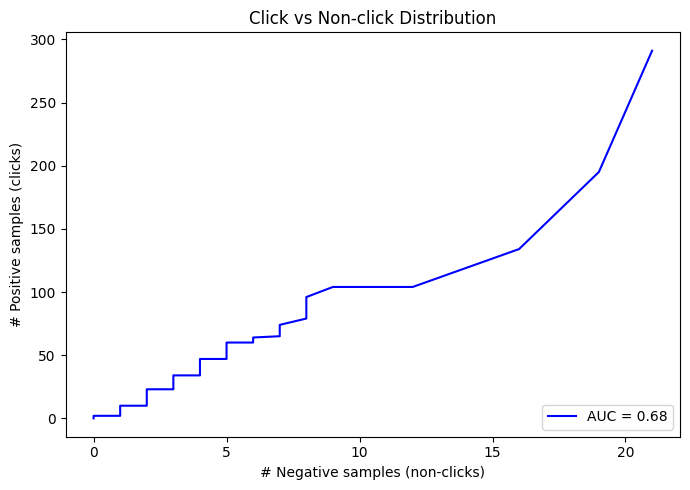

In [38]:
# Plot click count vs non-click count, both sorted independently by magnitude.
# This visualises the distribution of positive vs negative event volumes across
# test instances — not a true ROC curve, but useful for a quick sanity check.
import matplotlib.pyplot as plt

tpr = test['clicks'].sort_values()
fpr = (test['impressions'] - test['clicks']).sort_values()

plt.figure(figsize=(7, 5))
plt.plot(tpr, fpr, 'b', label='AUC = %0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.ylabel('# Positive samples (clicks)')
plt.xlabel('# Negative samples (non-clicks)')
plt.title('Click vs Non-click Distribution')
plt.tight_layout()
plt.show()

---
## 9. Feature Importance

`plot_importance` shows **weight-based importance** by default: the number of times
each feature is used to split across all trees in the ensemble. High weight means
the model frequently splits on that feature, but does not indicate how much each
split improves predictions. For a more informative view, try
`plot_importance(regr, importance_type='gain')` which reports average gain per split.

In [39]:
# Print raw feature importance scores as a numpy array (weight-based by default).
# Index order matches the column order of train_x.
from matplotlib import pyplot
print(regr.feature_importances_)

[0.0039029  0.         0.00296352 0.052591   0.24951848 0.00492733
 0.32696658 0.01644627 0.3280434  0.         0.         0.01464047]


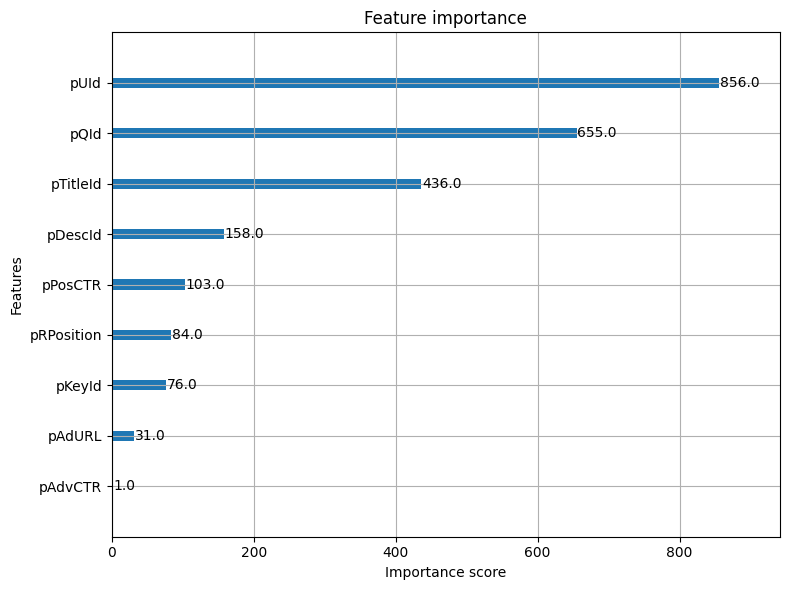

In [40]:
# Visualise feature importances.
# importance_type='weight' by default — counts how many times each feature
# is used across all trees. This favours features that appear in many splits,
# not necessarily the features with the largest individual effect.
# Passing ax= explicitly avoids creating a floating figure in newer xgboost versions.
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(8, 6))
plot_importance(regr, ax=ax)
pyplot.tight_layout()
pyplot.show()

---
## 10. What I Learned

1. **Rate features are the right tool for high-cardinality categoricals.** Replacing
   raw IDs with per-entity mean CTR (or pseudo-CTR) gave the model interpretable,
   smooth inputs without requiring embeddings or one-hot encoding — and the model
   ran comfortably on a single machine with 12 features instead of millions.

2. **Additive smoothing matters more than it looks.** Raw mean CTR is meaningless for
   entities with one or two impressions. The α=0.05, β=75 smoothing blended each
   entity's observed rate toward the global prior, dramatically stabilising predictions
   for long-tail ads and users.

3. **Shallow trees generalise better on smooth rate features.** The grid search showed
   that `max_depth=2` outperformed `depth=4` on the test set. Because the `p*` features
   are already continuous scalars, deeper splits captured noise rather than structure.

4. **The custom AUC captures ranking quality that accuracy misses.** A model predicting
   CTR = 0.02 uniformly would look acceptable by MAE but would score AUC ≈ 0.5 (random).
   The impression-weighted AUC penalises mis-ranking of high-impression ads most severely
   — exactly the cases that matter commercially.

5. **User identity, query context, and ad title history are the three dominant CTR signals.**
   pUId (856), pQId (655), and pTitleId (436) are the top three features by weight — and by total gain, pTitleId is nearly tied with pUId at 32.70% vs 32.80%, making ad title history almost as informative as user identity. The drop-off after these three is steep: pPosCTR sits at 103 and pAdvCTR at just 1. This tells us the model learned that who is searching, what they searched for, and which ad title they saw matter far more than advertiser identity or raw position.

   Three features — pAdCTR, pGender, and pAge — contributed zero importance across all trees. Advertiser-level CTR (pAdCTR) was likely too correlated with other entity-level rates to add independent signal. Gender and age being zero is consistent with the EDA finding that demographic differences in CTR were small (under 1 percentage point).

6. **The 7-file merge is the most fragile step in the pipeline.** Any mismatch between
   the loaded row count and the auxiliary tables introduces silent NaN. The null-checks
   after each feature-addition step are not optional — they are the only way to catch
   data-join failures before they silently corrupt the feature matrix.